In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("../data/student_marks.csv")


In [3]:
df.head(20)

,PreBoardMarks,Attendance,StudyHours,Assignments,SleepHours,FinalPercentage
0,78,90,4,1,7,82
1,65,80,3,1,6,70
2,35,55,1,0,5,40
3,50,60,2,0,6,52
4,88,95,5,1,8,91
5,45,58,1,0,5,48
6,72,85,3,1,7,76
7,30,40,1,0,4,35
8,91,97,6,1,8,95
9,55,65,2,1,6,60


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   PreBoardMarks    20 non-null     int64
 1   Attendance       20 non-null     int64
 2   StudyHours       20 non-null     int64
 3   Assignments      20 non-null     int64
 4   SleepHours       20 non-null     int64
 5   FinalPercentage  20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


,PreBoardMarks,Attendance,StudyHours,Assignments,SleepHours,FinalPercentage
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000
mean,63.850000,74.150000,3.000000,0.700000,6.400000,68.05000
std,19.367023,17.762394,1.777047,0.470162,1.187656,19.41642
min,30.000000,40.000000,1.000000,0.000000,4.000000,35.00000
25%,48.750000,59.500000,1.750000,0.000000,5.750000,51.00000
50%,66.500000,79.000000,3.000000,1.000000,6.500000,71.00000
75%,78.500000,88.500000,4.000000,1.000000,7.000000,82.75000
max,95.000000,99.000000,7.000000,1.000000,8.000000,98.00000


In [5]:
df.corr()

,PreBoardMarks,Attendance,StudyHours,Assignments,SleepHours,FinalPercentage
PreBoardMarks,1.000000,0.986286,0.952736,0.827133,0.970652,0.998660
Attendance,0.986286,1.000000,0.922086,0.843874,0.960040,0.987958
StudyHours,0.952736,0.922086,1.000000,0.692935,0.922696,0.950313
Assignments,0.827133,0.843874,0.692935,1.000000,0.791748,0.843478
SleepHours,0.970652,0.960040,0.922696,0.791748,1.000000,0.969096
FinalPercentage,0.998660,0.987958,0.950313,0.843478,0.969096,1.000000


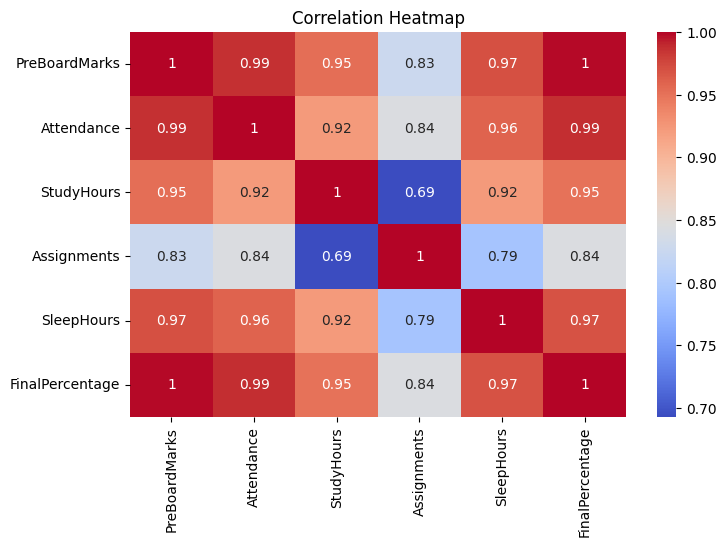

In [6]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

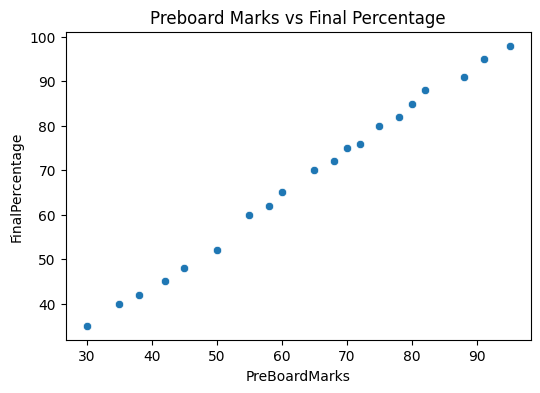

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['PreBoardMarks'],
    y=df['FinalPercentage']
)
plt.title("Preboard Marks vs Final Percentage")
plt.show()

In [29]:
X=df [['PreBoardMarks','Attendance','StudyHours','Assignments','SleepHours']]
y = df['FinalPercentage']

In [30]:
from sklearn.model_selection import train_test_split


In [31]:
X_train, X_test, y_train, y_test= train_test_split (X,y, test_size=0.2, random_state=72)

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
model=LinearRegression()

In [34]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
y_pred= model.predict(X_test)
print(y_pred)

[45.31244471 76.51375788 53.61387435 60.36690471]


In [36]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison

,Actual,Predicted
12,45,45.312445
6,76,76.513758
3,52,53.613874
9,60,60.366905


In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [39]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE or average prediction error:", mae)

MAE or average prediction error: 0.7017454121152813


In [41]:
mse = mean_squared_error(y_test, y_pred)

print("MSE (it punishes larger mistakes heavenly):", mse)

MSE (it punishes larger mistakes heavenly): 0.7751945836110702


In [43]:
rmse = np.sqrt(mse)

print("RMSE (tells how predictions are off by marks):", rmse)

RMSE (tells how predictions are off by marks): 0.8804513522115065


In [45]:
r2 = r2_score(y_test, y_pred)

print("R2 Score (how well the model explains data):", r2)

R2 Score (how well the model explains data): 0.9941796746420567


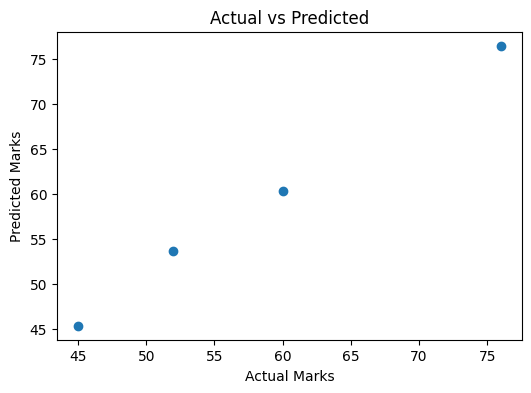

In [47]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")

plt.ylabel("Predicted Marks")

plt.title("Actual vs Predicted")

plt.show()

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [53]:
rf_model=RandomForestRegressor( n_estimators=100, random_state=23 )

In [54]:
rf_model.fit (X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [57]:
rf_pred= rf_model.predict(X_test)
print(rf_pred)

[43.38 75.99 53.68 61.06]


In [56]:
rf_mae= mean_absolute_error(y_test, rf_pred)
rf_rmse=np.sqrt( mean_squared_error(y_test,rf_pred))
rf_r2= r2_score(y_test, rf_pred)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 1.0925000000000011
RMSE: 1.281649328014492
R2 Score: 0.9876668230877522


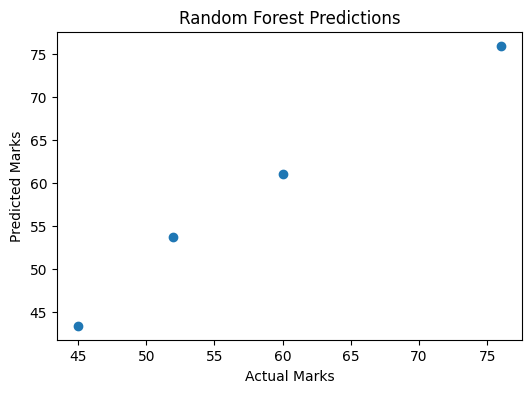

In [58]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Marks")

plt.ylabel("Predicted Marks")

plt.title("Random Forest Predictions")

plt.show()

In [59]:
importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df

,Feature,Importance
0,PreBoardMarks,0.297536
1,Attendance,0.244042
2,StudyHours,0.226998
3,Assignments,0.075673
4,SleepHours,0.155750


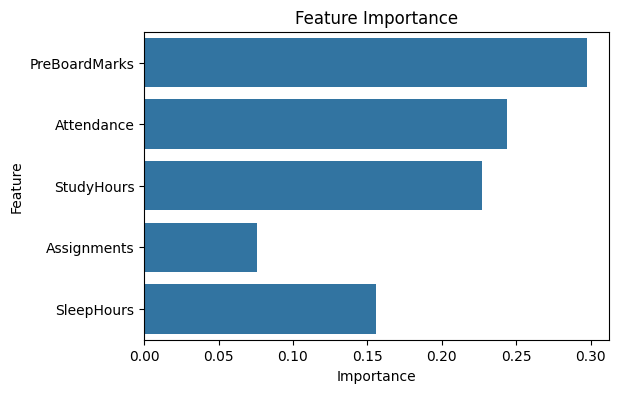

In [60]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

In [61]:
import joblib

In [62]:
joblib.dump(
    rf_model,
    "../models/marks_model.pkl"
)

['../models/marks_model.pkl']